In [1]:
import snp2cell
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
csvFile = pd.read_csv("../process/SNP/SNP2ell/20250215_network_table_1000.csv",index_col=0)

In [3]:
G = nx.from_pandas_edgelist(
        csvFile,
        source='TF',  # source column name
        target='gene',  # target column name
        edge_attr='width'  # weight column name (optional)
    )

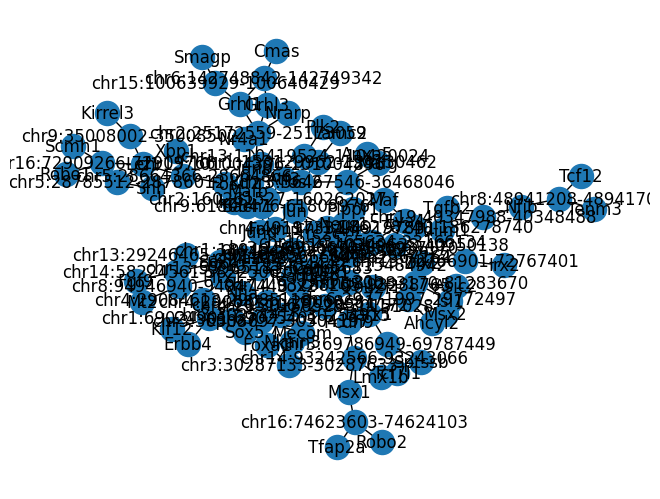

In [4]:
nx.draw_kamada_kawai(G, with_labels=True)

In [5]:
s2c = snp2cell.SNP2CELL()
s2c.add_grn_from_networkx(G)

In [6]:
snpscore = pd.read_csv("../process/framework/snps/20250213_SNPs_annoated_peaks_scenic.csv",index_col=0)
peak = snpscore["seqnames"] + ":" + snpscore["start"].astype(str) + "-" + snpscore["end"].astype(str)
peak_snp_dict =  {k: v for k, v in zip(peak, snpscore['has_snp'])}

In [7]:
gene_snp = pd.read_csv("../process/SNP/SNP2ell/20250206_prepare_gene_snp.csv",index_col=0)
gene_snp_dict ={k: v for k, v in zip(gene_snp["symbol"], gene_snp['has_snp'])}
peak_snp_dict.update(gene_snp_dict)

In [8]:
ad = sc.read("../process/framework/obj/rna_raw_scglue_prepare.h5ad")
ad.X = ad.layers["counts"].copy()

sc.pp.normalize_total(ad)
sc.pp.log1p(ad)
ad.raw = ad

In [14]:
ad.obs_names

Index(['E125_1_AAACCCAAGTCATGAA-1', 'E125_1_AAACCCACAAGACCGA-1',
       'E125_1_AAACCCACATGCACTA-1', 'E125_1_AAACCCAGTCAGTCGC-1',
       'E125_1_AAACCCAGTCCACGCA-1', 'E125_1_AAACCCAGTCCGTACG-1',
       'E125_1_AAACCCAGTCGACTTA-1', 'E125_1_AAACGAAAGCCTATTG-1',
       'E125_1_AAACGAACAGCTCCTT-1', 'E125_1_AAACGAAGTGCGGTAA-1',
       ...
       'E145_2_TTTGGAGAGGGATGTC-1', 'E145_2_TTTGGAGCACAGTACT-1',
       'E145_2_TTTGGAGCATGACAGG-1', 'E145_2_TTTGGTTAGAGGTCAC-1',
       'E145_2_TTTGGTTCAGTTGTTG-1', 'E145_2_TTTGGTTCATACCATG-1',
       'E145_2_TTTGGTTCATGCCGGT-1', 'E145_2_TTTGGTTTCGTAGGAG-1',
       'E145_2_TTTGTTGCACACCGAC-1', 'E145_2_TTTGTTGTCAACTGGT-1'],
      dtype='object', length=19404)

In [15]:
label

,level1_anno,level2_anno
E125_1_AAACCCAAGTCATGAA-1,stem cells,stem1
E125_1_AAACCCACAAGACCGA-1,stem cells,stem1
E125_1_AAACCCACATGCACTA-1,Transit,Transit 4
E125_1_AAACCCAGTCAGTCGC-1,stem cells,stem2
E125_1_AAACCCAGTCCACGCA-1,stem cells,stem1
...,...,...
E145_2_TTTGGTTCATACCATG-1,K5(-),K5(-)
E145_2_TTTGGTTCATGCCGGT-1,K5(-),K5(-)
E145_2_TTTGGTTTCGTAGGAG-1,Transit,Transit 2
E145_2_TTTGTTGCACACCGAC-1,Transit,Transit 2


In [9]:
label = pd.read_csv("../../2024.4_scATAC/processed_data/cluster/rna_annotation_scvi_mod.csv",index_col=0)

In [10]:
ad.obs["label"] = label["level1_anno"]

In [11]:
s2c.add_score(score_dct=peak_snp_dict, score_key="has_snp")

[INFO - add_score - 2025-02-15 11:54:33,618]: adding score: has_snp
[INFO - add_score - 2025-02-15 11:54:34,090]: propagating score: has_snp
[INFO - add_score - 2025-02-15 11:54:34,116]: storing score has_snp
[INFO - rand_sim - 2025-02-15 11:54:34,120]: ----- starting rand_sim -----
[INFO - rand_sim - 2025-02-15 11:54:34,122]: create 1000 permutations of score has_snp
[INFO - rand_sim - 2025-02-15 11:54:34,248]: propagating permutations
[INFO - loop_parallel - 2025-02-15 11:54:34,249]: using 48 cores
100%|██████████| 1000/1000 [00:12<00:00, 78.63it/s]
[INFO - rand_sim - 2025-02-15 11:54:48,609]: storing scores under key has_snp
[INFO - rand_sim - 2025-02-15 11:54:48,659]: ----- finished rand_sim -----
[INFO - add_score_statistics - 2025-02-15 11:54:48,662]: ----- starting add_score_statistics -----
[INFO - add_score_statistics - 2025-02-15 11:54:48,664]: adding statistics for: has_snp
[INFO - add_score_statistics - 2025-02-15 11:54:49,096]: ----- finished add_score_statistics -----


In [12]:
s2c.link_adata(ad,overwrite=True)
s2c.adata_add_de_scores(groupby="label", check=False)

[INFO - adata_add_de_scores - 2025-02-15 11:54:49,352]: ----- starting adata_add_de_scores -----
[INFO - adata_add_de_scores - 2025-02-15 11:54:49,354]: finding DE genes for annotation label
[INFO - adata_add_de_scores - 2025-02-15 11:56:30,906]: ranking by upregulation...
[INFO - add_score - 2025-02-15 11:56:30,946]: adding score: DE_stem cells__score
[INFO - add_score - 2025-02-15 11:56:31,354]: adding score: DE_K5(-)__score
[INFO - add_score - 2025-02-15 11:56:31,639]: adding score: DE_Transit__score
[INFO - add_score - 2025-02-15 11:56:31,924]: adding score: DE_Mature K5(-) __score
[INFO - add_score - 2025-02-15 11:56:32,210]: adding score: DE_K6+ cells__score
[INFO - add_score - 2025-02-15 11:56:32,494]: adding score: DE_K14(-)__score
[INFO - add_score - 2025-02-15 11:56:32,778]: adding score: DE_Shh(+)__score
[INFO - propagate_scores - 2025-02-15 11:56:33,051]: ----- starting propagate_scores -----
[INFO - propagate_scores - 2025-02-15 11:56:33,053]: propagating scores: ['DE_stem

In [16]:
s2c.adata_combine_de_scores(
    group_key="label", score_key="has_snp", suffix="__zscore"
)

[INFO - combine_scores - 2025-02-15 11:59:17,472]: ----- starting combine_scores -----
[INFO - combine_scores - 2025-02-15 11:59:17,475]: combining scores: [('DE_stem cells__score__zscore', 'has_snp__zscore'), ('DE_K5(-)__score__zscore', 'has_snp__zscore'), ('DE_Transit__score__zscore', 'has_snp__zscore'), ('DE_Mature K5(-) __score__zscore', 'has_snp__zscore'), ('DE_K6+ cells__score__zscore', 'has_snp__zscore'), ('DE_K14(-)__score__zscore', 'has_snp__zscore'), ('DE_Shh(+)__score__zscore', 'has_snp__zscore')]
[INFO - combine_scores - 2025-02-15 11:59:17,491]: ----- finished combine_scores -----
[INFO - combine_scores_rand - 2025-02-15 11:59:17,493]: ----- starting combine_scores_rand -----
[INFO - combine_scores_rand - 2025-02-15 11:59:17,495]: combining scores: [('DE_label__score', 'has_snp', '__zscore')]
[INFO - combine_scores_rand - 2025-02-15 11:59:17,858]: ----- finished combine_scores_rand -----
[INFO - add_score_statistics - 2025-02-15 11:59:17,860]: ----- starting add_score_stat

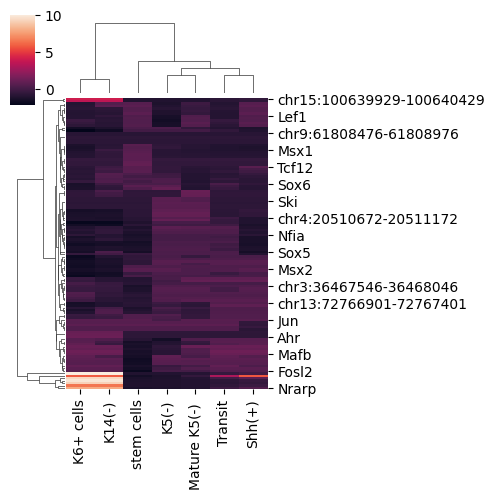

In [30]:
plt_df = s2c.get_scores(regex="min.+has_snp__zscore.*zscore$")
plt_df = plt_df.rename(columns=s2c.rename_column)

sns.clustermap(plt_df, figsize=(5, 5),vmax = 10)
plt.savefig("../result/SNP/20250213_snp2cell_round1/20250215_GRN_hm3.pdf")

In [37]:
s2c.scores[s2c.scores["has_snp"]!=0]

,has_snp,DE_stem cells__score,DE_K5(-)__score,DE_Transit__score,DE_Mature K5(-) __score,DE_K6+ cells__score,DE_K14(-)__score,DE_Shh(+)__score
Grhl3,1.0,0.0,0.0,0.0,0.0,0.865457,0.881427,0.0


In [42]:
s2c.scores_prop[s2c.scores_prop["has_snp"]!=0]

,has_snp,has_snp__pval,has_snp__FDR,has_snp__zscore,has_snp__zscore_mad,DE_stem cells__score,DE_Transit__score,DE_K14(-)__score,DE_Mature K5(-) __score,DE_K6+ cells__score,...,"min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore","min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore_mad","min(DE_K14(-)__score__zscore,has_snp__zscore)__pval","min(DE_K14(-)__score__zscore,has_snp__zscore)__FDR","min(DE_K14(-)__score__zscore,has_snp__zscore)__zscore","min(DE_K14(-)__score__zscore,has_snp__zscore)__zscore_mad","min(DE_Shh(+)__score__zscore,has_snp__zscore)__pval","min(DE_Shh(+)__score__zscore,has_snp__zscore)__FDR","min(DE_Shh(+)__score__zscore,has_snp__zscore)__zscore","min(DE_Shh(+)__score__zscore,has_snp__zscore)__zscore_mad"
Atf3,0.004828,0.218,0.764651,-0.177849,2.288331,0.001525,0.025642,0.011584,0.013611,0.018047,...,0.751442,0.926056,0.103,0.650526,0.751442,0.926056,0.103,0.657778,0.751442,0.926056
chr1:153129962-153130462,0.003163,0.236,0.764651,-0.206076,1.795520,0.001110,0.013941,0.007647,0.007518,0.012086,...,0.637963,0.577921,0.134,0.765714,0.597200,0.515033,0.110,0.657778,0.637963,0.577921
chr13:110419524-110420024,0.003163,0.236,0.764651,-0.200681,1.795520,0.001110,0.013941,0.015525,0.007518,0.028586,...,0.685367,0.777681,0.096,0.640000,0.685367,0.777681,0.096,0.657778,0.685367,0.777681
chr2:160261527-160262027,0.032132,0.202,0.764651,0.068204,2.357750,0.009495,0.070530,0.053150,0.029377,0.069081,...,1.143092,1.971183,0.088,0.621176,1.143092,1.971183,0.088,0.657778,1.143092,1.971183
Fosl2,0.006085,0.264,0.764651,-0.271871,1.332015,0.002412,0.019516,0.014838,0.010886,0.023894,...,0.501636,0.829574,0.148,0.807273,0.501636,0.829574,0.148,0.657778,0.501636,0.829574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Otx1,0.000002,0.024,0.260000,-0.153055,0.987774,0.014732,0.000001,0.000001,0.000001,0.000001,...,-0.430209,-0.483018,0.642,0.986000,-0.430209,-0.483018,0.642,0.938824,-0.430209,-0.483018
chr3:156936670-156937170,0.000002,0.758,0.770420,-0.156219,-0.326348,0.019604,0.000004,0.000004,0.000004,0.000004,...,-0.513302,0.629155,0.344,0.986000,-0.513302,0.629155,0.344,0.842222,-0.513302,0.629155
Negr1,0.000002,0.024,0.260000,-0.152621,0.987774,0.008331,0.000001,0.000001,0.000001,0.000001,...,-0.528438,-0.483018,0.642,0.986000,-0.528438,-0.483018,0.642,0.938824,-0.528438,-0.483018
Plppr1,0.000668,0.450,0.770420,-0.184784,0.198097,0.024551,0.006719,0.001732,0.001350,0.001525,...,-0.368333,-0.343322,0.559,0.986000,-0.254069,-0.192478,0.146,0.657778,0.484841,0.782972


In [26]:
plt_df.to_csv("../process/SNP/SNP2ell/20250215_heatmap_res_df_2.csv")

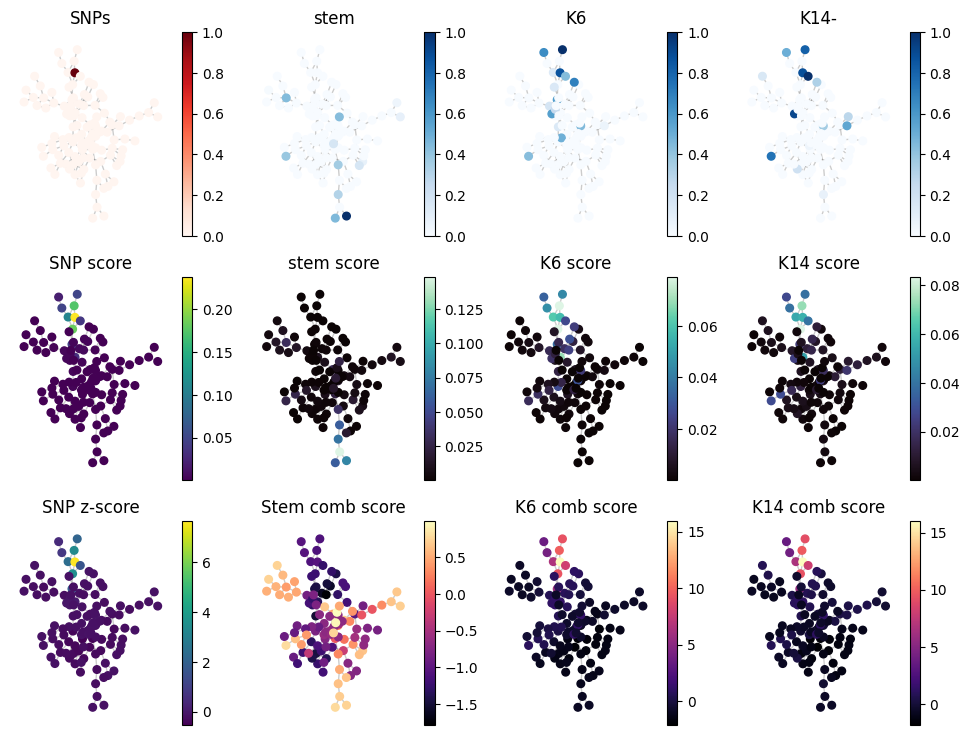

In [19]:
plot_scores = [
    (s2c.scores["has_snp"], "Reds", "SNPs"),
    (s2c.scores["DE_stem cells__score"], "Blues", "stem"),
    (s2c.scores["DE_K6+ cells__score"], "Blues", "K6"),
    (s2c.scores["DE_K14(-)__score"], "Blues", "K14-"),
    (s2c.scores_prop["has_snp"], "viridis", "SNP score"),
    (s2c.scores_prop["DE_stem cells__score"], "mako", "stem score"),
    (s2c.scores_prop["DE_K6+ cells__score"], "mako", "K6 score"),
    (s2c.scores_prop["DE_K14(-)__score"], "mako", "K14 score"),
    (s2c.scores_prop["has_snp__zscore"], "viridis", "SNP z-score"),
    (
        s2c.scores_prop["min(DE_stem cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Stem comb score",
    ),
    (
        s2c.scores_prop["min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K6 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K14(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K14 comb score",
    ),
]
nrow, ncol = 3, 4
plt.rcParams["figure.figsize"] = (ncol * 3, nrow * 3)
fig, axs = plt.subplots(nrow, ncol)
pos = nx.kamada_kawai_layout(G)
for k, (score_val, col_map, ax_title) in enumerate(plot_scores):
    i, j = int(k) // 4, k % 4
    ec = nx.draw_networkx_edges(G, pos, alpha=0.2, ax=axs[i, j])
    nc = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=s2c.scores_prop.index.tolist(),
        node_color=score_val.tolist(),
        node_size=30,
        cmap=plt.colormaps[col_map],
        ax=axs[i, j],
    )
    plt.colorbar(nc)
    axs[i, j].set_title(ax_title)
    axs[i, j].axis("off")

plt.savefig("../result/SNP/20250213_snp2cell_round1/20250216_GRN_snp3.pdf")

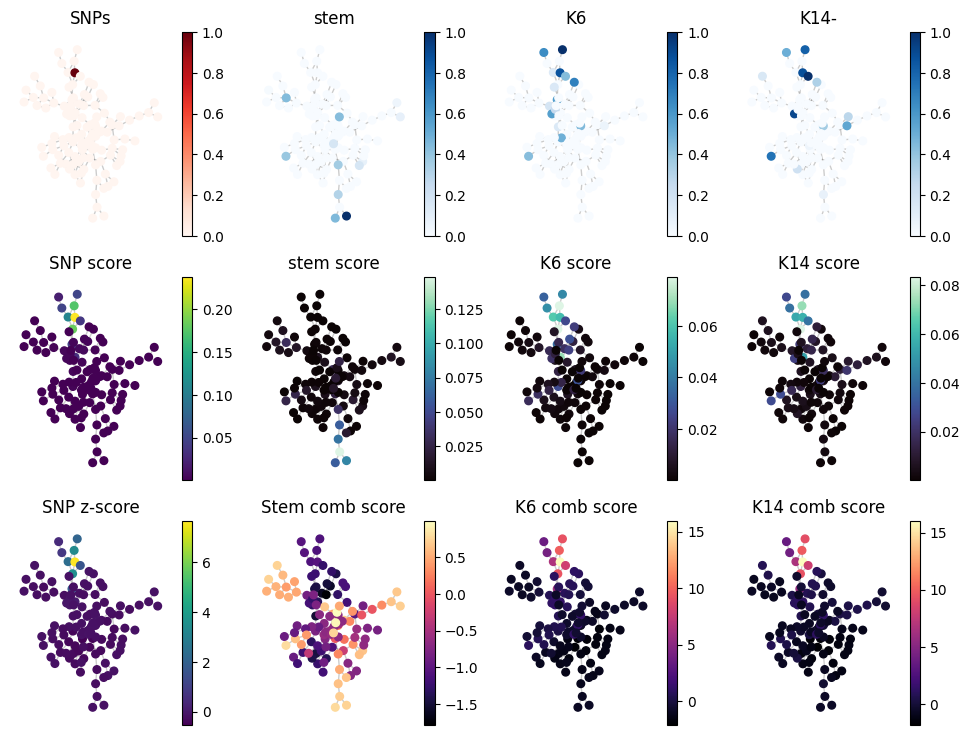

In [43]:
plot_scores = [
    (s2c.scores["has_snp"], "Reds", "SNPs"),
    (s2c.scores["DE_stem cells__score"], "Blues", "stem"),
    (s2c.scores["DE_K6+ cells__score"], "Blues", "K6"),
    (s2c.scores["DE_K14(-)__score"], "Blues", "K14-"),
    (s2c.scores_prop["has_snp"], "viridis", "SNP score"),
    (s2c.scores_prop["DE_stem cells__score"], "mako", "stem score"),
    (s2c.scores_prop["DE_K6+ cells__score"], "mako", "K6 score"),
    (s2c.scores_prop["DE_K14(-)__score"], "mako", "K14 score"),
    (s2c.scores_prop["has_snp__zscore"], "viridis", "SNP z-score"),
    (
        s2c.scores_prop["min(DE_stem cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Stem comb score",
    ),
    (
        s2c.scores_prop["min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K6 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K14(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K14 comb score",
    ),
]
nrow, ncol = 3, 4
plt.rcParams["figure.figsize"] = (ncol * 3, nrow * 3)
fig, axs = plt.subplots(nrow, ncol)
pos = nx.kamada_kawai_layout(G)
for k, (score_val, col_map, ax_title) in enumerate(plot_scores):
    i, j = int(k) // 4, k % 4
    ec = nx.draw_networkx_edges(G, pos, alpha=0.2, ax=axs[i, j])
    nc = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=s2c.scores_prop.index.tolist(),
        node_color=score_val.tolist(),
        node_size=30,
        cmap=plt.colormaps[col_map],
        ax=axs[i, j],
    )
    plt.colorbar(nc)
    axs[i, j].set_title(ax_title)
    axs[i, j].axis("off")

plt.savefig("../result/SNP/20250213_snp2cell_round1/20250216_GRN_snp3.pdf")

In [21]:
ad.obs["label"]

E125_1_AAACCCAAGTCATGAA-1    stem cells
E125_1_AAACCCACAAGACCGA-1    stem cells
E125_1_AAACCCACATGCACTA-1       Transit
E125_1_AAACCCAGTCAGTCGC-1    stem cells
E125_1_AAACCCAGTCCACGCA-1    stem cells
                                ...    
E145_2_TTTGGTTCATACCATG-1         K5(-)
E145_2_TTTGGTTCATGCCGGT-1         K5(-)
E145_2_TTTGGTTTCGTAGGAG-1       Transit
E145_2_TTTGTTGCACACCGAC-1       Transit
E145_2_TTTGTTGTCAACTGGT-1       Transit
Name: label, Length: 19404, dtype: category
Categories (7, object): ['K5(-)', 'K6+ cells', 'K14(-)', 'Mature K5(-) ', 'Shh(+)', 'Transit', 'stem cells']

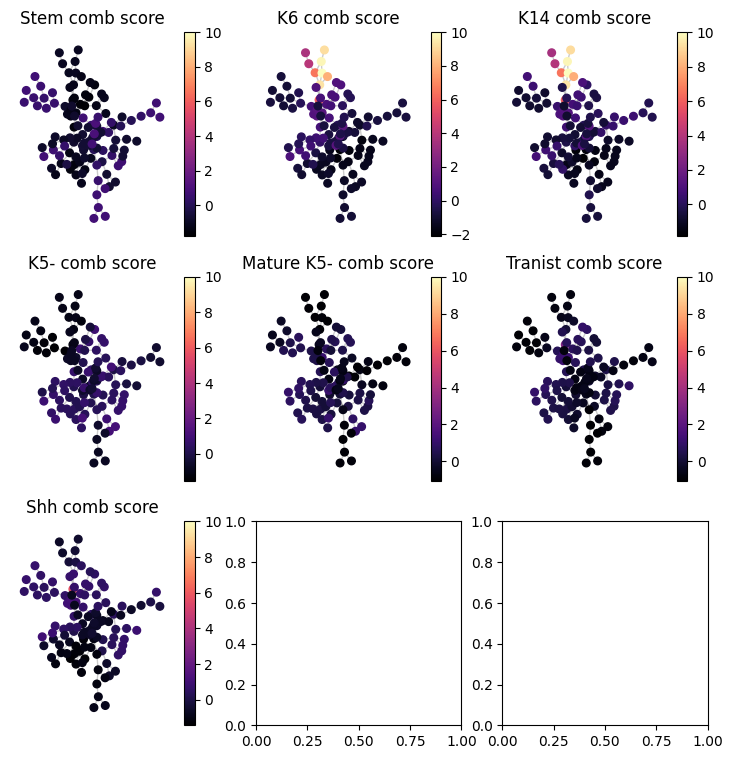

In [25]:
plot_scores = [
    (
        s2c.scores_prop["min(DE_stem cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Stem comb score",
    ),
    (
        s2c.scores_prop["min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K6 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K14(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K14 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K5(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K5- comb score",
    ),
    (
        s2c.scores_prop["min(DE_Mature K5(-) __score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Mature K5- comb score",
    ),
    (
        s2c.scores_prop["min(DE_Transit__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Tranist comb score",
    ),
    (
        s2c.scores_prop["min(DE_Shh(+)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Shh comb score",
    ),
]
nrow, ncol = 3, 3
plt.rcParams["figure.figsize"] = (ncol * 3, nrow * 3)
fig, axs = plt.subplots(nrow, ncol)
pos = nx.kamada_kawai_layout(G)
for k, (score_val, col_map, ax_title) in enumerate(plot_scores):
    i, j = int(k) // 3, k % 3
    ec = nx.draw_networkx_edges(G, pos, alpha=0.2, ax=axs[i, j])
    nc = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=s2c.scores_prop.index.tolist(),
        node_color=score_val.tolist(),
        node_size=30,
        cmap=plt.colormaps[col_map],
        ax=axs[i, j],
        vmax = 10
    )
    plt.colorbar(nc)
    axs[i, j].set_title(ax_title)
    axs[i, j].axis("off")
plt.savefig("../result/SNP/20250213_snp2cell_round1/20250216_GRN_snp3_celltype.pdf")

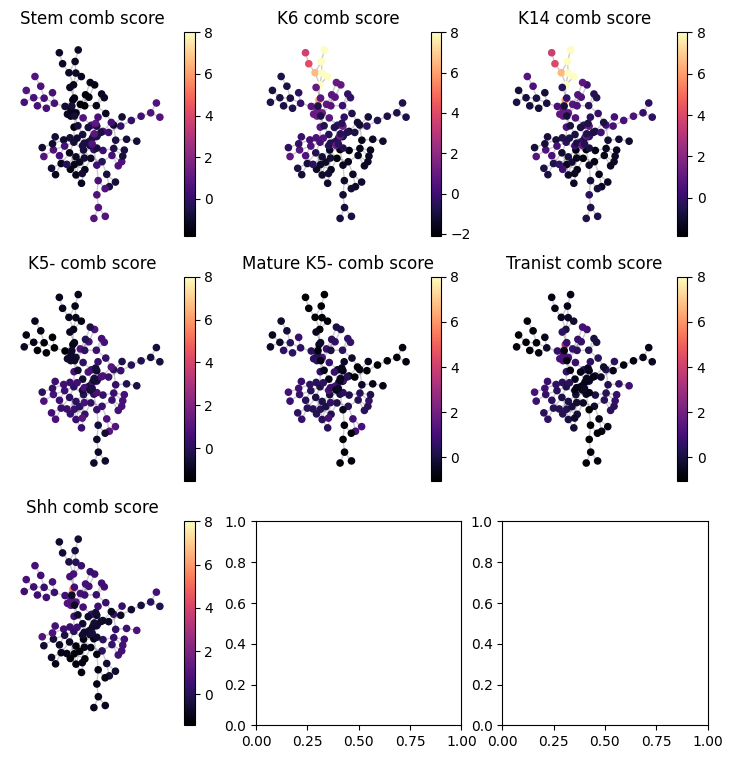

In [29]:
plot_scores = [
    (
        s2c.scores_prop["min(DE_stem cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Stem comb score",
    ),
    (
        s2c.scores_prop["min(DE_K6+ cells__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K6 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K14(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K14 comb score",
    ),
    (
        s2c.scores_prop["min(DE_K5(-)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "K5- comb score",
    ),
    (
        s2c.scores_prop["min(DE_Mature K5(-) __score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Mature K5- comb score",
    ),
    (
        s2c.scores_prop["min(DE_Transit__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Tranist comb score",
    ),
    (
        s2c.scores_prop["min(DE_Shh(+)__score__zscore,has_snp__zscore)__zscore"],
        "magma",
        "Shh comb score",
    ),
]
nrow, ncol = 3, 3
plt.rcParams["figure.figsize"] = (ncol * 3, nrow * 3)
fig, axs = plt.subplots(nrow, ncol)
pos = nx.kamada_kawai_layout(G)
for k, (score_val, col_map, ax_title) in enumerate(plot_scores):
    i, j = int(k) // 3, k % 3
    ec = nx.draw_networkx_edges(G, pos, alpha=0.2, ax=axs[i, j])
    nc = nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=s2c.scores_prop.index.tolist(),
        node_color=score_val.tolist(),
        node_size=20,
        cmap=plt.colormaps[col_map],
        ax=axs[i, j],
        vmax = 8
    )
    plt.colorbar(nc)
    axs[i, j].set_title(ax_title)
    axs[i, j].axis("off")

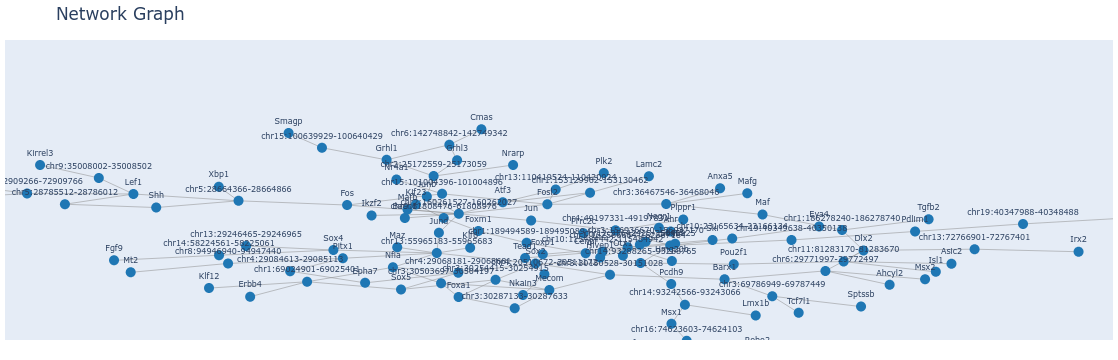

In [27]:
import plotly.graph_objects as go
import numpy as np

# Get Kamada-Kawai layout positions
pos = nx.kamada_kawai_layout(G)

# Create edge traces
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'
)

# Create node traces
node_x = []
node_y = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    hoverinfo='text',
    text=list(G.nodes()),  # Node labels
    textposition="top center",
    marker=dict(
        size=10,
        color='#1f77b4',
    ),
    textfont=dict(
        size=8
    )
)

# Create figure
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title='Network Graph',
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=20,l=5,r=5,t=40),
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
                ))

# Show the figure
fig.show()

# Optionally save to HTML
fig.write_html("network_graph.html")